RNN

An RNN does not remember every row separately. It continuously compresses previous information into a hidden state (context), which is updated at every time step.

seq_len tells us how many times the RNN runs. input_size tells us how much information the RNN receives at each run.

#Download the Dataset

In [1]:
from torchvision import datasets
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]

Training Images : 60000
Testing Images  : 10000


# Data analysis

In [2]:
image , label=train_dataset[0]
print("Label :", label)
print("Image Shape :", image.shape)
print("Data Type :", image.dtype)



# PyTorch stores images as:

# (Channel, Height, Width)


# The content of the image changes, but the shape remains the same because every MNIST image has the same dimensions.

Label : 5
Image Shape : torch.Size([1, 28, 28])
Data Type : torch.float32


#Visualization

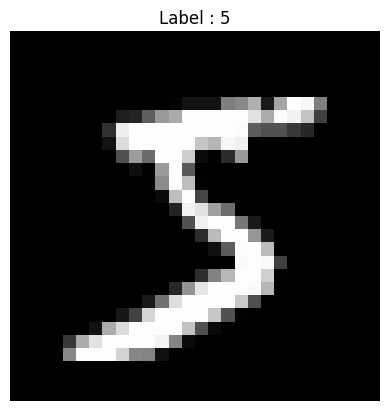

In [3]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label : {label}")
plt.axis("off")
plt.show()

Explore the Dataset

In [4]:
print("Training Samples :", len(train_dataset))
print("Testing Samples  :", len(test_dataset))

print("\nType of Image :", type(image))
print("Type of Label :", type(label))

print("\nImage Shape :", image.shape)
print("Label :", label)

print("\nClasses :", train_dataset.classes)

Training Samples : 60000
Testing Samples  : 10000

Type of Image : <class 'torch.Tensor'>
Type of Label : <class 'int'>

Image Shape : torch.Size([1, 28, 28])
Label : 5

Classes : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


# creating Dataloader

In [5]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
# Inspect One Batch

images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("\nImage Data Type :", images.dtype)
print("Label Data Type :", labels.dtype)




# This is the first time you'll see a 4-dimensional tensor.

# (Batch, Channel, Height, Width)

# This format is the standard input for CNNs.

# Later, before feeding images to the RNN, we'll reshape them because an RNN expects sequences, not 4D image tensors.

Images Shape : torch.Size([64, 1, 28, 28])
Labels Shape : torch.Size([64])

Image Data Type : torch.float32
Label Data Type : torch.int64


Define the RNN Model

In [7]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        # Remove channel dimension
        x = x.squeeze(1)

        # Initial hidden state
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=x.device
        )

        # Forward pass through RNN
        out, _ = self.rnn(x, h0)

        # Take output of hidden state from last time step
        out = out[:, -1, :]

        # Classification layer
        out = self.fc(out)

        return out

#creating or initializing the model

In [8]:
input_size = 28
sequence_length = 28

hidden_size = 128
num_layers = 2
num_classes = 10

model = RNNModel(
    input_size,
    hidden_size,
    num_layers,
    num_classes
)

print(model)

RNNModel(
  (rnn): RNN(28, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
# cross Entropy loss function , bcz we have multi class classification

criterion = nn.CrossEntropyLoss()

# using adam optimizer
# Adam combines the advantages of momentum and adaptive learning rates, making it a strong default optimizer.
learning_rate = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

# Training

In [10]:
num_epochs = 10

for epoch in range(num_epochs):

    for images, labels in train_loader:

        # Forward Pass
        outputs = model(images)

        # Calculate Loss
        loss = criterion(outputs, labels)

        # Clear Previous Gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")




#   It switches the model to evaluation mode.

# Effects:

# Dropout → OFF
# BatchNorm → Uses learned statistics instead of batch statistics

# Our RNN doesn't have Dropout or BatchNorm, but it is still a good practice to call model.eval() before testing.

Epoch [1/10], Loss: 0.2328
Epoch [2/10], Loss: 0.0928
Epoch [3/10], Loss: 0.2532
Epoch [4/10], Loss: 0.0299
Epoch [5/10], Loss: 0.0756
Epoch [6/10], Loss: 0.1865
Epoch [7/10], Loss: 0.0793
Epoch [8/10], Loss: 0.1656
Epoch [9/10], Loss: 0.0613
Epoch [10/10], Loss: 0.0142


# Testing the Model

In [11]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)  # torch.max(..., 1) returns: Maximum value = 5.2 ,Index = 2

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 96.06%


# save the model

In [12]:
from google.colab import drive
drive.mount('/content/drive')


torch.save(model, "/content/drive/MyDrive/MNIST - DL/models/mnist_rnn.pth")


# Why save only state_dict()?

# Because it saves only the learned parameters (weights and biases), making the file smaller and more portable. This is the recommended PyTorch practice.

Mounted at /content/drive


# Load the model

                         MNIST RNN CLASSIFICATION
═══════════════════════════════════════════════════════════════════════════════

                           INPUT IMAGE
                     Grayscale Digit (28 × 28)

                           Shape
                        (1, 28, 28)
                               │
                               │
                               ▼
                    ToTensor() + Normalize
                               │
                               ▼
                    DataLoader (Batch = 64)
                               │
                               ▼
                     Batch Shape
                  (64, 1, 28, 28)
                               │
                               │
                    x = x.squeeze(1)
             Remove Channel Dimension
                               │
                               ▼
                     RNN Input Shape
                    (64, 28, 28)

         Batch = 64
         Sequence Length = 28 rows
         Input Size = 28 pixels per row

═══════════════════════════════════════════════════════════════════════════════

                    Initial Hidden State

                h0 = zeros(num_layers,
                           batch_size,
                           hidden_size)

                      Shape
                  (2, 64, 128)

═══════════════════════════════════════════════════════════════════════════════

                        RNN LAYER

                input_size  = 28
                hidden_size = 128
                num_layers  = 2

                    batch_first = True

                         │
                         ▼

Output Shape

(64, 28, 128)

Meaning

64  → Batch Size

28  → Time Steps

128 → Hidden Features

═══════════════════════════════════════════════════════════════════════════════

Take ONLY Last Time Step

out = out[:, -1, :]

Shape becomes

(64,128)

Reason:
Last hidden representation summarizes all 28 rows.

═══════════════════════════════════════════════════════════════════════════════

                    Fully Connected Layer

              Linear(128 → 10)

Input

(64,128)

↓

Output

(64,10)

═══════════════════════════════════════════════════════════════════════════════

                    Softmax (inside CrossEntropyLoss)

↓

Probability for every digit

Example

[0.01 0.00 0.05 0.82 0.02 0.03 0.01 0.04 0.01 0.01]

↓

Predicted Class

Digit = 3

═══════════════════════════════════════════════════════════════════════════════